In [5]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td

Récupération des données 

In [6]:
ids= td.get_movie_ids_list(3, headers=td.headers)
df=td.get_movies_info(ids,headers=td.headers)
df1=td.drop_useless_info(df)
df1=td.keep_main_genre(df1)
df1=td.full_poster_path(df1)
df1.head()
df1.describe()
df1.shape

getting movie ids


100%|██████████| 3/3 [00:01<00:00,  1.93it/s]


getting movie info


100%|██████████| 60/60 [00:07<00:00,  8.47it/s]


(60, 13)

On remarque que qu'il y'a des données où le budget n'est pas renseigné, en effet on a min budget égal à 0.

In [7]:
df1=df1.loc[df1["budget"]!=0] # on supprime les lignes où le budget n'est pas renseigné, l'imputation est possible par le budget moyen, pour le moment on fait le choix de ne pas imputer
df1.shape

(49, 13)

On va créer une colonne comptant le nombre de mots caractères dans le synopsis 

In [8]:
df1["overview_count"]=df1["overview"].map(len)
df1.head()
df1.shape

(49, 14)

Nous allons encoder les genres pour la regression linéaire : méthode one hot encoding

In [9]:
df1["main_genre_name"].unique() 

array(['Drama', 'Comedy', 'Romance', 'Family', 'Adventure', 'Horror',
       'Action', 'Thriller', 'Fantasy', 'Animation', 'Music', 'Crime',
       'History'], dtype=object)

In [10]:
#Méthode : OneHotEncoder
for genre in df1["main_genre_name"].unique() :
    df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int) 
df1.shape
df1.head()

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,...,main_genre_name_Family,main_genre_name_Adventure,main_genre_name_Horror,main_genre_name_Action,main_genre_name_Thriller,main_genre_name_Fantasy,main_genre_name_Animation,main_genre_name_Music,main_genre_name_Crime,main_genre_name_History
0,13000000,77338,A true story of two men who should never have ...,44.588,2011-11-02,426590315,113,The Intouchables,8.276,17209,...,0,0,0,0,0,0,0,0,0,0
1,10000000,194,"At a tiny Parisian café, the adorable yet pain...",45.387,2001-04-25,173921954,122,Amélie,7.914,11494,...,0,0,0,0,0,0,0,0,0,0
2,4300000,152584,"Adèle's life is changed when she meets Emma, a...",35.826,2013-10-09,19465835,180,Blue Is the Warmest Color,7.089,4556,...,0,0,0,0,0,0,0,0,0,0
3,2600000,406,After a chaotic night of rioting in a marginal...,27.171,1995-05-31,15300000,98,La Haine,8.092,4038,...,0,0,0,0,0,0,0,0,0,0
4,58500000,2899,The Egyptian Queen Cleopatra bets against the ...,28.874,2002-01-30,128027976,108,Asterix & Obelix: Mission Cleopatra,7.389,3494,...,1,0,0,0,0,0,0,0,0,0


Nous allons essayer de prédire la note c'est à dire vote_average à partir des variables suivantes :

In [11]:
df1["main_genre_name"].unique()
L=[]
for i in df1["main_genre_name"].unique() : 
    L.append("main_genre_name"+"_"+str(i))
print(L)

var_explicative=["id","vote_average","budget","runtime","overview_count"]
var_explicative.extend(L)
df1=df1.loc[:,var_explicative]
df1.head(1)


['main_genre_name_Drama', 'main_genre_name_Comedy', 'main_genre_name_Romance', 'main_genre_name_Family', 'main_genre_name_Adventure', 'main_genre_name_Horror', 'main_genre_name_Action', 'main_genre_name_Thriller', 'main_genre_name_Fantasy', 'main_genre_name_Animation', 'main_genre_name_Music', 'main_genre_name_Crime', 'main_genre_name_History']


,id,vote_average,budget,runtime,overview_count,main_genre_name_Drama,main_genre_name_Comedy,main_genre_name_Romance,main_genre_name_Family,main_genre_name_Adventure,main_genre_name_Horror,main_genre_name_Action,main_genre_name_Thriller,main_genre_name_Fantasy,main_genre_name_Animation,main_genre_name_Music,main_genre_name_Crime,main_genre_name_History
0,77338,8.276,13000000,113,154,1,0,0,0,0,0,0,0,0,0,0,0,0


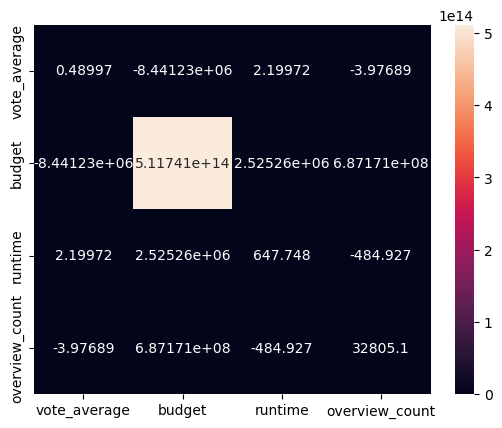

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cov = np.cov(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(cov, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()


/tmp/ipykernel_54269/2385372420.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)


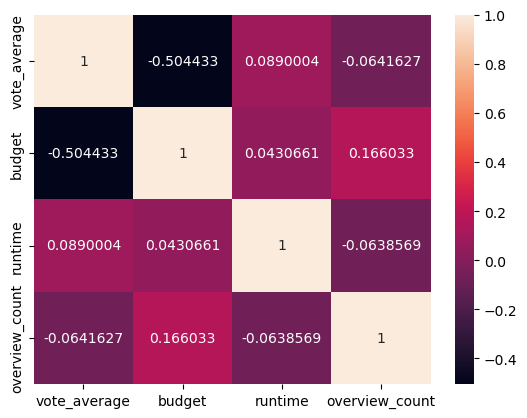

In [9]:


corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Si on rajoute main_genre_name_Drama :

/tmp/ipykernel_54269/4188107850.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","main_genre_name_Drama"]].T, bias=True)


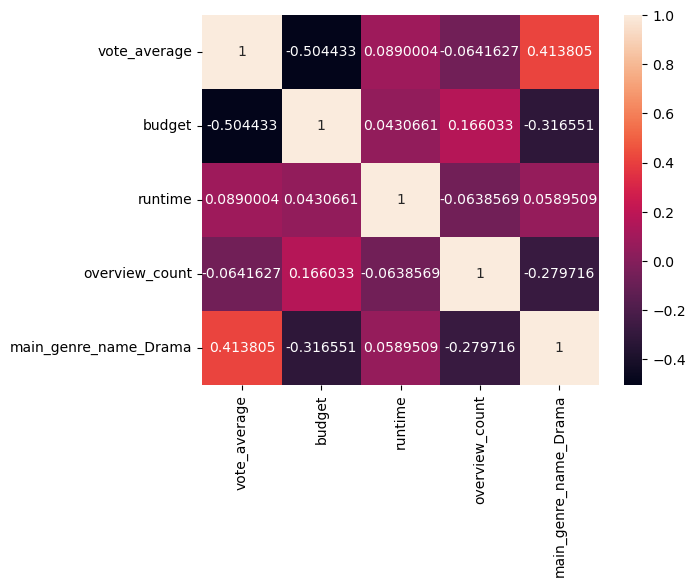

In [10]:
corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","main_genre_name_Drama"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","main_genre_name_Drama"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Normalisation et Standardisation des données : pas nécessaire dans la regression linéaire car le modèle ne sélectionne pas en fonction des poids, ce qui arrive dans les modèles de clustering. 

Régression linéaire :

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X=df1.loc[:,~df1.columns.isin(['id', 'vote_average']) ]
Y=df1[["vote_average"]]
X.head()
Y.head()
#random_state=42, vous vous assurez que la division des données sera la même à chaque exécution du code. Cela est particulièrement utile pour la reproductibilité des expériences, car cela garantit que vous obtenez exactement les mêmes ensembles d'entraînement et de test chaque fois que vous exécutez votre code.

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #80% de train
#X_train.shape
#X_test.shape

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-1.97137428e-08  2.47932954e-03  1.34621254e-04  6.52891457e-02
  -3.31077780e-01 -4.79922365e-01  9.73108589e-01  2.49775500e-01
  -1.83609064e-02 -6.34703906e-01  3.29316879e-01 -5.30089536e-01
   1.57203559e-01  3.18362405e-01 -1.52495414e-01  5.35938296e-02]]
Ordonnée à l'origine (intercept) : [7.1755069]
Erreur quadratique moyenne (MSE) : 0.25872436418670314
Score R2 : 0.38577880616828153


Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [ ]:
import statsmodels.api as sm


# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)
r2 = model.rsquared
print(f"R² : {r2}")
# la différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 80% sur sklearn 

#Afficher la T-stat pour runtime
T_stat_runtime=model.tvalues["runtime"]
print(T_stat_runtime)

#Zone de rejet de niveau 5% pour notre test d'hypothèse : 
from scipy.stats import norm
quantile = norm.ppf(1-5/200, loc=0, scale=1)
if T_stat_runtime >= quantile or T_stat_runtime <= - quantile : 
    print("le coef théorique devant runtime est trop proche de 0, on le rejete")
else: 
    print("on conserve la variable explicative runtime")


                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     2.706
Date:                Tue, 03 Dec 2024   Prob (F-statistic):            0.00840
Time:                        14:21:18   Log-Likelihood:                -32.399
No. Observations:                  49   AIC:                             96.80
Df Residuals:                      33   BIC:                             127.1
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [37]:
# Généralisation : 
var_explicative_significative_au_niv_5=[]
X.columns
for var_explicative in X.columns:
    if model.tvalues[var_explicative] >= quantile or model.tvalues[var_explicative] <= - quantile : 
        print("le coef théorique devant ", var_explicative , "est trop proche de 0, on le rejete")
    else: 
        print("on conserve la variable explicative:",var_explicative)
        var_explicative_significative_au_niv_5.append(var_explicative)
print(quantile)
print(var_explicative_significative_au_niv_5)
    

le coef théorique devant  const est trop proche de 0, on le rejete
le coef théorique devant  budget est trop proche de 0, on le rejete
on conserve la variable explicative: runtime
on conserve la variable explicative: overview_count
le coef théorique devant  main_genre_name_Drama est trop proche de 0, on le rejete
on conserve la variable explicative: main_genre_name_Comedy
on conserve la variable explicative: main_genre_name_Romance
le coef théorique devant  main_genre_name_Family est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Adventure est trop proche de 0, on le rejete
on conserve la variable explicative: main_genre_name_Horror
on conserve la variable explicative: main_genre_name_Action
on conserve la variable explicative: main_genre_name_Thriller
on conserve la variable explicative: main_genre_name_Fantasy
on conserve la variable explicative: main_genre_name_Animation
on conserve la variable explicative: main_genre_name_Music
on conserve la variable expl